# Rainfall-runoff model using MF-LSTM

**General Description**

The following notebook contains the code to create, train, validate, and test a rainfall-runoff model using an LSTM network architecture. The code allows for the creation of single-basin models but is conceptualized to create regional models. The code is intended as an initial introduction to the topic, prioritizing interpretability over modularity.

The logic of the code is heavily based on [Neural Hydrology](https://doi.org/10.21105/joss.04050) [1]. For a more flexible, robust, and modular implementation of deep learning methods in hydrological modeling, we advise the use of Neural Hydrology. 

**Experiment Details**
- In this example we use the MF-LSTM (multi-frequency LSTM) architecture, which allow us to work the data at different frequencies (daily/hourly). 
- This experiment use a similar setup as the experiments presented in [2].

**Authors:**
- Eduardo Acuña Espinoza (eduardo.espinoza@kit.edu)

**References:**

[1]: Kratzert, F., Gauch, M., Nearing, G., & Klotz, D. (2022). NeuralHydrology – A Python library for deep learning research in hydrology. Journal of Open Source Software, 7, 4050. https://doi.org/10.21105/joss.04050

[2]: Gauch, M., Kratzert, F., Klotz, D., Nearing, G., Lin, J., & Hochreiter, S. (2021). Rainfall–runoff prediction at multiple timescales with a single long short-term memory network. Hydrology and Earth System Sciences, 25(4), 2045–2062. https://doi.org/10.5194/hess-25-2045-2021


In [1]:
# Import necessary packages
import pickle
import random
import sys
import time
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# sys.path.append("..")
# Import classes and functions from other files
from hy2dl.aux_functions.functions_evaluation import nse
from hy2dl.aux_functions.functions_training import nse_basin_averaged
from hy2dl.aux_functions.utils import Optimizer, create_folder, set_random_seed, upload_to_device, write_report
from hy2dl.datasetzoo.hourlycamelsde import HourlyCAMELS_DE as Datasetclass
from hy2dl.modelzoo.mflstm import MFLSTM as modelclass

## 1. Initialize information

In [2]:
# Define experiment name
experiment_name = "test_output_1_step_GPU"

# # paths to access the information
# path_entities = r"D:\Research\Projects\Hy2DL\data\basin_id\basins_camels_de_hourly_5.txt"
# path_data = r"D:\Research\Projects\Hy2DL\data\CAMELS_DE"

# paths to access the information
path_entities = "/pfs/data6/home/ka/ka_iwu/ka_qa8171/Project/Hy2DL/data/basin_id/basins_camels_de_hourly_5.txt"
path_data = "/pfs/data6/home/ka/ka_iwu/ka_qa8171/Project/Hy2DL/data/CAMELS_DE/"

# dynamic forcings and target
dynamic_input = {
    "1W": [
       "precipitation_resampled",
       "air_temperature_mean_mean",
       "global_shortwave_radiation_mean",
    #    "air_pressure_surface_mean",
       "relative_humidity_mean",
       "wind_speed_mean",
    ],
    "1D": [
        "precipitation_resampled",
        "air_temperature_mean_mean",
        "global_shortwave_radiation_mean",
        # "air_pressure_surface_mean",
        "relative_humidity_mean",
        "wind_speed_mean",
        #"discharge_spec_obs",
    ],
    "1h": [
        "precipitation_sum_mean",
        "air_temperature_mean_mean",
        "global_shortwave_radiation_mean",
        # "air_pressure_surface_mean",
        "relative_humidity_mean",
        "wind_speed_mean",
        #"discharge_spec_obs",
    ]
}

target = ["discharge_spec_obs"]

# static attributes that will be used. If one is not using static_inputs, initialize the variable as an empty list.
static_input = [
    "area",
    "elev_mean",
    "clay_0_30cm_mean",
    "sand_0_30cm_mean",
    "silt_0_30cm_mean",
    "artificial_surfaces_perc",
    "agricultural_areas_perc",
    "forests_and_seminatural_areas_perc",
    "wetlands_perc",
    "water_bodies_perc",
    "p_mean",
    "p_seasonality",
    "frac_snow",
    "high_prec_freq",
    "low_prec_freq",
    "high_prec_dur",
    "low_prec_dur",
]

# # time periods
training_period = ["2001-01-01 01:00:00", "2015-12-31 23:00:00"]
validation_period = ["2016-01-01 01:00:00", "2018-12-31 23:00:00"]
testing_period = ["2019-01-01 01:00:00", "2023-12-31 23:00:00"]


# model configuration
model_configuration = {
    "n_dynamic_channels_lstm": 5,
    "no_of_layers": 1,
    "seq_length": 365 * 24,  # 1 year of hourly data
    "custom_freq_processing": {
        "1W": {
           "n_steps": 24,  # 24 weeks (6 months)
           "freq_factor": 168,  # 24*7 hours in a week
        },
        "1D": {
           "n_steps": 196,  # ~2 months (197 - 1 days)
           "freq_factor": 24,  # 24 hours in a day
        },
        "1h": {
           "n_steps": 1 * 24,  # 1 days of hourly data
           "freq_factor": 1
        }
        # "1D": {
        #     "n_steps": 351,
        #     "freq_factor": 24,
        # },
        # "1h": {"n_steps": (365 - 351) * 24,
        #        "freq_factor": 1}
    },
    "predict_last_n": 1,            
    "unique_prediction_blocks": True, # with predict_last_n > 1, simulations overlap and in evaluation there are multiple y_sim for each timestep -> set to true in evaluation, for training it just reduces the number of sample 
    "dynamic_embeddings": True,
    "hidden_size": 128,
    "batch_size_training": 256,
    "batch_size_evaluation": 1024,
    "no_of_epochs": 30, # 30
    "dropout_rate": 0.4,
    "learning_rate": {1: 5e-4, 2: 1e-4, 3: 1e-5},  # {1: 5e-4, 10: 1e-4, 25: 1e-5}
    "set_forget_gate": 3,
    "validate_every": 1, # 5
    "validate_n_random_basins": -1,
}

# device to train the model
running_device = "gpu"  # cpu or gpu

# define random seed
seed = 110

# colorblind friendly palette
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

## 2. Calculate additional information necessary for the model

In [3]:
# Create folder to store the results
path_save_folder = "./results/" + experiment_name + "_seed_" + str(seed)
create_folder(folder_path=path_save_folder)

Folder './results/test_output_1_step_GPU_seed_110' created successfully.


In [4]:
# save model config
model_config = {
    "name": experiment_name,
    "input": {
        "dynamic": dynamic_input,
        "static": static_input
    },
    "target": target,
    "time_periods": {
        "training": training_period,
        "validation": validation_period,
        "testing": testing_period
    },
    "hyperparameters": model_configuration,
    "random_seed": seed
}

# write to json
with open(path_save_folder + "/model_config.json", "w") as f:
    json.dump(model_config, f, indent=4)

In [5]:
# check if model will be run in gpu or cpu and define device
if running_device == "gpu":
    print(torch.cuda.get_device_name(0))
    device = "cuda:0"
elif running_device == "cpu":
    device = "cpu"

NVIDIA A100 80GB PCIe


In [6]:
# include information about input size for each frequency
if isinstance(dynamic_input, list):
    model_configuration["dynamic_input_size"] = len(dynamic_input)
elif isinstance(dynamic_input, dict):
    model_configuration["dynamic_input_size"] = {key: len(value) for key, value in dynamic_input.items()}

# include information about input size for lstm
model_configuration["input_size_lstm"] = model_configuration["n_dynamic_channels_lstm"] + len(static_input)
# if I am processing multiple frequencies and do not have custom dynamic embeddings for each frequency, I add an
# additional channel that will be used as a flag to indicate the frequency.
if model_configuration.get("custom_freq_processing") and not model_configuration.get("dynamic_embeddings"):
    model_configuration["input_size_lstm"] = model_configuration["input_size_lstm"] + 1

# If predict_last_n was not defined, we initialize it as 1
if not model_configuration.get("predict_last_n"):
    model_configuration["predict_last_n"] = 1

# Check connection between predict_last_n and unique_prediction_blocks. If predict_last_n is larger than 1, and
# unique_prediction_blocks is False, we change for evaluation purposes predict_last_n to 1. This avoid having
# multiple predictions for the same time step due to the overlap of the sequences.
if model_configuration.get("predict_last_n", 1) > 1 and not model_configuration.get("unique_prediction_blocks"):
    print(
        (
            "Warning: predict_last_n > 1 and unique_prediction_blocks = False."
            + " This creates overlapping sequences during evaluation. To avoid this, predict_last_n will be changed to"
            + " 1 during evaluation (validation / testing). This will not affect the training process."
        )
    )
    model_configuration["predict_last_n_evaluation"] = 1
else:
    model_configuration["predict_last_n_evaluation"] = model_configuration.get("predict_last_n", 1)

## 3. Class to create the dataset object used in training

In [7]:
# Dataset training
training_dataset = Datasetclass(
    dynamic_input=dynamic_input,
    target=target,
    sequence_length=model_configuration["seq_length"],
    time_period=training_period,
    path_data=path_data,
    path_entities=path_entities,
    check_NaN=True,
    predict_last_n=model_configuration["predict_last_n"],
    static_input=static_input,
    custom_freq_processing=model_configuration["custom_freq_processing"],
    dynamic_embedding=model_configuration["dynamic_embeddings"],
    unique_prediction_blocks=model_configuration["unique_prediction_blocks"],
)

training_dataset.calculate_basin_std()
training_dataset.calculate_global_statistics(path_save_scaler=path_save_folder)
training_dataset.standardize_data()

In [8]:
# Dataloader training
train_loader = DataLoader(
    dataset=training_dataset,
    batch_size=model_configuration["batch_size_training"],
    shuffle=True,
    drop_last=True,
    collate_fn=training_dataset.collate_fn,
)

# Print details of a loader´s sample to see that our format is correct
print("Number of batches in training: ", len(train_loader))
print("\nSample batch details:")
print(f"{'Key':<12} | {'Shape':<20}")
print("-" * 35)
# Loop through the sample dictionary and print the shape of each element
for key, value in next(iter(train_loader)).items():
    print(f"{key:<12} | {str(value.shape):<20}")

Number of batches in training:  983

Sample batch details:
Key          | Shape               
-----------------------------------
x_d_1W       | torch.Size([256, 24, 5])
x_d_1D       | torch.Size([256, 196, 5])
x_d_1h       | torch.Size([256, 24, 5])
x_s          | torch.Size([256, 17])
y_obs        | torch.Size([256, 1, 1])
basin_std    | torch.Size([256, 1, 1])
basin        | (256,)              
date         | (256, 1)            


## 4. Create dataset for validation

In [9]:
# In evaluation (validation and testing) we will create an individual dataset per basin. This will give us more 
# flexibility
entities_ids = np.loadtxt(path_entities, dtype="str").tolist()
entities_ids = [entities_ids] if isinstance(entities_ids, str) else entities_ids
validation_dataset = {}
for entity in entities_ids:
    dataset = Datasetclass(
        dynamic_input=dynamic_input,
        target=target,
        sequence_length=model_configuration["seq_length"],
        time_period=validation_period,
        path_data=path_data,
        entity=entity,
        check_NaN=False,
        predict_last_n=model_configuration["predict_last_n_evaluation"],
        static_input=static_input,
        custom_freq_processing=model_configuration["custom_freq_processing"],
        dynamic_embedding=model_configuration["dynamic_embeddings"],
        unique_prediction_blocks=model_configuration["unique_prediction_blocks"],
    )

    dataset.scaler = training_dataset.scaler
    dataset.standardize_data(standardize_output=False)
    validation_dataset[entity] = dataset

## 5. Train Model

In [10]:
# construct model
set_random_seed(seed=seed)
model = modelclass(model_configuration=model_configuration).to(device)

# optimizer
optimizer = Optimizer(model=model, model_configuration=model_configuration)

# set forget gate to 3 to ensure that the model is capable to learn long term dependencies
model.lstm.bias_hh_l0.data[model_configuration["hidden_size"] : 2 * model_configuration["hidden_size"]] = (
    model_configuration["set_forget_gate"]
)

training_time = time.time()
# Loop through the different epochs
for epoch in range(1, model_configuration["no_of_epochs"] + 1):
    epoch_start_time = time.time()
    total_loss = []
    # Training -------------------------------------------------------------------------------------------------------
    model.train()
    for idx, sample in enumerate(train_loader):
        # maximum iterations per epoch
        if (
            model_configuration.get("max_updates_per_epoch") is not None
            and idx >= model_configuration["max_updates_per_epoch"]
        ):
            break
        sample = upload_to_device(sample, device)  # upload tensors to device
        optimizer.optimizer.zero_grad()  # sets gradients of weigths and bias to zero
        pred = model(sample)  # forward call

        loss = nse_basin_averaged(y_sim=pred["y_hat"], y_obs=sample["y_obs"], per_basin_target_std=sample["basin_std"])

        loss.backward()  # backpropagates

        optimizer.clip_grad_and_step(epoch, idx)  # clip gradients and update weights

        total_loss.append(loss.item())

        # remove from cuda
        del sample, pred
        torch.cuda.empty_cache()

    # training report
    report = f"Epoch: {epoch:<2} | Loss training: {'%.3f ' % (np.mean(total_loss))}"

    # Validation -----------------------------------------------------------------------------------------------------
    if epoch % model_configuration["validate_every"] == 0:
        model.eval()
        validation_results = {}
        with torch.no_grad():
            # If we define validate_n_random_basins as 0 or negative, we take all the basins
            if model_configuration["validate_n_random_basins"] <= 0:
                validation_basin_ids = validation_dataset.keys()
            else:
                keys = list(validation_dataset.keys())
                validation_basin_ids = random.sample(keys, model_configuration["validate_n_random_basins"])

            # go through each basin that will be used for validation
            for basin in validation_basin_ids:
                loader = DataLoader(
                    dataset=validation_dataset[basin],
                    batch_size=model_configuration["batch_size_evaluation"],
                    shuffle=False,
                    drop_last=False,
                    collate_fn=validation_dataset[basin].collate_fn,
                )

                df_ts = pd.DataFrame()
                for sample in loader:
                    sample = upload_to_device(sample, device)
                    pred = model(sample)
                    # backtransformed information
                    y_sim = pred["y_hat"] * validation_dataset[basin].scaler["y_std"].to(device) + validation_dataset[
                        basin
                    ].scaler["y_mean"].to(device)

                    # join results in a dataframe and store them in a dictionary (is easier to plot later)
                    df = pd.DataFrame(
                        {
                            "y_obs": sample["y_obs"].flatten().cpu().detach(),
                            "y_sim": y_sim[:, -model_configuration["predict_last_n_evaluation"] :, :]
                            .flatten()
                            .cpu()
                            .detach(),
                        },
                        index=pd.to_datetime(sample["date"].flatten()),
                    )

                    df_ts = pd.concat([df_ts, df], axis=0)

                    # remove from cuda
                    del sample, pred, y_sim
                    torch.cuda.empty_cache()

                validation_results[basin] = df_ts

            # average loss validation
            loss_validation = nse(df_results=validation_results)
            report += f"| NSE validation: {'%.3f ' % (loss_validation)}"

    # save model after every epoch
    path_saved_model = path_save_folder + "/epoch_" + str(epoch)
    torch.save(model.state_dict(), path_saved_model)

    # print epoch report
    report += (
        f"| Epoch time: {'%.1f ' % (time.time() - epoch_start_time)} s | "
        f"LR:{'%.5f ' % (optimizer.optimizer.param_groups[0]['lr'])}"
    )
    print(report)
    write_report(file_path=path_save_folder + "/run_progress.txt", text=report)
    # modify learning rate
    optimizer.update_optimizer_lr(epoch=epoch)

# print final report
report = f"Total training time: {'%.1f ' % (time.time() - training_time)} s"
print(report)
write_report(file_path=path_save_folder + "/run_progress.txt", text=report)


/pfs/data6/home/ka/ka_iwu/ka_qa8171/envs/HY3.9/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Epoch: 1  | Loss training: 23.478 | NSE validation: 0.556 | Epoch time: 239.5  s | LR:0.00050 
Epoch: 2  | Loss training: 9.672 | NSE validation: 0.766 | Epoch time: 234.8  s | LR:0.00050 
Total training time: 474.3  s


## 6. Test LSTM

In [7]:
path_save_folder = "results/MFLSTM_hourly_de_test_seed_110/"

# Load a pre-trained model from model weight
model_weight = "epoch_5"
model_weight_path = os.path.join(path_save_folder, model_weight)

model = modelclass(model_configuration=model_configuration).to(device)
model.load_state_dict(torch.load(model_weight_path, map_location=device))

# Load the scaler
# (1) we can use training scaler
# scaler = training_dataset.scaler

# (2) we can read a previously stored one
with open(path_save_folder + "/scaler.pickle", "rb") as file:
  scaler = pickle.load(file)

In [8]:
# In evaluation (validation and testing) we will create an individual dataset per basin. This will give us more 
# flexibility
entities_ids = np.loadtxt(path_entities, dtype="str").tolist()
entities_ids = [entities_ids] if isinstance(entities_ids, str) else entities_ids
testing_dataset = {}
for entity in entities_ids:
    dataset = Datasetclass(
        dynamic_input=dynamic_input,
        target=target,
        sequence_length=model_configuration["seq_length"],
        time_period=testing_period,
        path_data=path_data,
        entity=entity,
        check_NaN=False,
        predict_last_n=model_configuration["predict_last_n_evaluation"],
        static_input=static_input,
        custom_freq_processing=model_configuration["custom_freq_processing"],
        dynamic_embedding=model_configuration["dynamic_embeddings"],
        unique_prediction_blocks=model_configuration["unique_prediction_blocks"],
    )

    dataset.scaler = scaler
    dataset.standardize_data(standardize_output=False)
    testing_dataset[entity] = dataset

In [9]:
model.eval()
test_results = {}
with torch.no_grad():
    for basin, dataset in testing_dataset.items():
        loader = DataLoader(
            dataset=dataset,
            batch_size=model_configuration["batch_size_evaluation"],
            shuffle=False,
            drop_last=False,
            collate_fn=testing_dataset[basin].collate_fn,
        )

        df_ts = pd.DataFrame()
        for sample in loader:
            sample = upload_to_device(sample, device)  # upload tensors to device
            pred = model(sample)
            # backtransformed information
            y_sim = pred["y_hat"] * dataset.scaler["y_std"].to(device) + dataset.scaler["y_mean"].to(device)

            # join results in a dataframe and store them in a dictionary (is easier to plot later)
            df = pd.DataFrame(
                {
                    "y_obs": sample["y_obs"].flatten().cpu().detach(),
                    "y_sim": y_sim[:, -model_configuration["predict_last_n_evaluation"] :, :].flatten().cpu().detach(),
                },
                index=pd.to_datetime(sample["date"].flatten()),
            )

            df_ts = pd.concat([df_ts, df], axis=0)

            # remove from cuda
            del sample, pred, y_sim
            torch.cuda.empty_cache()

        test_results[basin] = df_ts

# Save results as a pickle file
with open(path_save_folder + "/test_results.pickle", "wb") as f:
    pickle.dump(test_results, f)

In [ ]:
# import math

# # do testing in batches of catchments
# # Load all entity IDs
# entities_ids = np.loadtxt(path_entities, dtype="str").tolist()
# entities_ids = [entities_ids] if isinstance(entities_ids, str) else entities_ids

# # Define batch size for processing catchments
# catchment_batch_size = 200  # Adjust based on your memory constraints
# total_catchments = len(entities_ids)
# num_batches = math.ceil(total_catchments / catchment_batch_size)

# # Create directory for intermediate results if it doesn't exist
# intermediate_results_dir = os.path.join(path_save_folder, "intermediate_results")
# os.makedirs(intermediate_results_dir, exist_ok=True)

# # Process entities in batches
# model.eval()
# all_test_results = {}

# for batch_idx in range(num_batches):
#     batch_filename = f"test_results_batch_{batch_idx+1}.pickle"
#     if os.path.exists(os.path.join(intermediate_results_dir, batch_filename)):
#         print(f"Skipping catchment batch {batch_idx+1}/{num_batches}")
#         continue
        
#     print(f"Processing catchment batch {batch_idx+1}/{num_batches}")
    
#     # Get current batch of entities
#     start_idx = batch_idx * catchment_batch_size
#     end_idx = min((batch_idx + 1) * catchment_batch_size, total_catchments)
#     batch_entities = entities_ids[start_idx:end_idx]
    
#     # Create dataset for current batch of entities
#     batch_testing_dataset = {}
#     for entity in batch_entities:
#         dataset = Datasetclass(
#             dynamic_input=dynamic_input,
#             target=target,
#             sequence_length=model_configuration["seq_length"],
#             time_period=testing_period,
#             path_data=path_data,
#             entity=entity,
#             check_NaN=False,
#             predict_last_n=model_configuration["predict_last_n_evaluation"],
#             static_input=static_input,
#             custom_freq_processing=model_configuration["custom_freq_processing"],
#             dynamic_embedding=model_configuration["dynamic_embeddings"],
#             unique_prediction_blocks=model_configuration["unique_prediction_blocks"],
#         )
#         dataset.scaler = scaler
#         dataset.standardize_data(standardize_output=False)
#         batch_testing_dataset[entity] = dataset
    
#     # Process each entity in the current batch
#     batch_results = {}
#     with torch.no_grad():
#         for basin, dataset in batch_testing_dataset.items():
#             loader = DataLoader(
#                 dataset=dataset,
#                 batch_size=model_configuration["batch_size_evaluation"],
#                 shuffle=False,
#                 drop_last=False,
#                 collate_fn=batch_testing_dataset[basin].collate_fn,
#             )
#             df_ts = pd.DataFrame()
#             for sample in loader:
#                 sample = upload_to_device(sample, device)  # upload tensors to device
#                 pred = model(sample)
#                 # backtransformed information
#                 y_sim = pred["y_hat"] * dataset.scaler["y_std"].to(device) + dataset.scaler["y_mean"].to(device)
#                 # join results in a dataframe
#                 df = pd.DataFrame(
#                     {
#                         "y_obs": sample["y_obs"].flatten().cpu().detach(),
#                         "y_sim": y_sim[:, -model_configuration["predict_last_n_evaluation"] :, :].flatten().cpu().detach(),
#                     },
#                     index=pd.to_datetime(sample["date"].flatten()),
#                 )
#                 df_ts = pd.concat([df_ts, df], axis=0)
#                 # remove from cuda
#                 del sample, pred, y_sim
#                 torch.cuda.empty_cache()
#             batch_results[basin] = df_ts
            
#             # Optional: Update all_test_results dictionary to maintain complete results
#             all_test_results[basin] = df_ts
    
#     # Save intermediate results for this batch
#     batch_filename = f"test_results_batch_{batch_idx+1}.pickle"
#     with open(os.path.join(intermediate_results_dir, batch_filename), "wb") as f:
#         pickle.dump(batch_results, f)
    
#     # Clear memory
#     del batch_testing_dataset, batch_results
#     torch.cuda.empty_cache()
    
#     print(f"Completed batch {batch_idx+1}/{num_batches}, saved to {batch_filename}")


Processing catchment batch 1/1
Completed batch 1/1, saved to test_results_batch_1.pickle


In [ ]:
# def combine_batch_results(results_dir):
#     """Combine all batch results into a single dictionary"""
#     combined_results = {}
#     batch_files = [f for f in os.listdir(results_dir) if f.startswith("test_results_batch_") and f.endswith(".pickle")]
    
#     for batch_file in sorted(batch_files):
#         print("Processing batch file" + batch_file)
#         with open(os.path.join(results_dir, batch_file), "rb") as f:
#             batch_results = pickle.load(f)
#             combined_results.update(batch_results)
    
#     return combined_results

# # Example usage of the helper function:

# test_results = combine_batch_results(intermediate_results_dir)
# with open(os.path.join(path_save_folder, "test_results.pickle"), "wb") as f:
#     pickle.dump(test_results, f)

Processing batch filetest_results_batch_1.pickle


## 7. Initial analysis

In [ ]:
# Loss testing
loss_testing = nse(df_results=test_results, average=False)
df_NSE = pd.DataFrame(data={"basin_id": test_results.keys(), "NSE": np.round(loss_testing, 3)})
df_NSE = df_NSE.set_index("basin_id")
df_NSE.to_csv(path_save_folder + "/NSE_testing.csv", index=True, header=True)

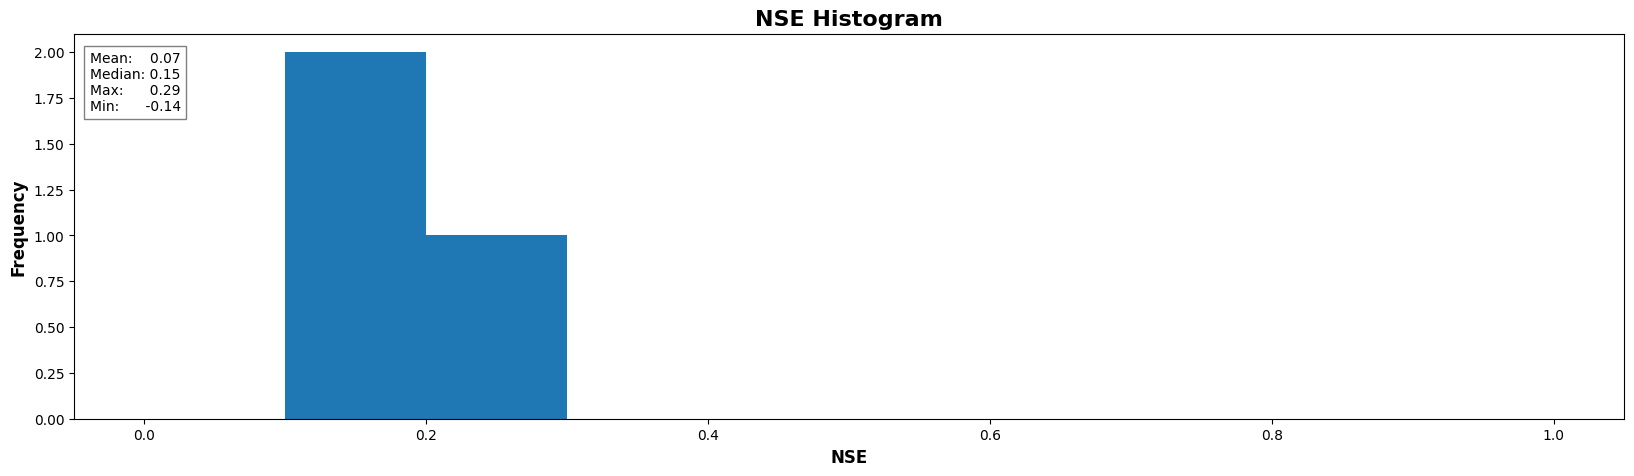

In [17]:
# Plot the histogram
plt.hist(df_NSE["NSE"], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

# Add NSE statistics to the plot
plt.text(
    0.01,
    0.8,
    (
        f'Mean: {"%.2f" % df_NSE["NSE"].mean():>7}\n'
        f'Median: {"%.2f" % df_NSE["NSE"].median():>0}\n'
        f'Max: {"%.2f" % df_NSE["NSE"].max():>9}\n'
        f'Min: {"%.2f" % df_NSE["NSE"].min():>10}'
    ),
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", alpha=0.5),
)

# Format plot
plt.rcParams["figure.figsize"] = (20, 5)
plt.xlabel("NSE", fontsize=12, fontweight="bold")
plt.ylabel("Frequency", fontsize=12, fontweight="bold")
plt.title("NSE Histogram", fontsize=16, fontweight="bold")
# plt.savefig(save_folder+"/NSE_Histogram.png", bbox_inches="tight", pad_inches=0)
plt.show()

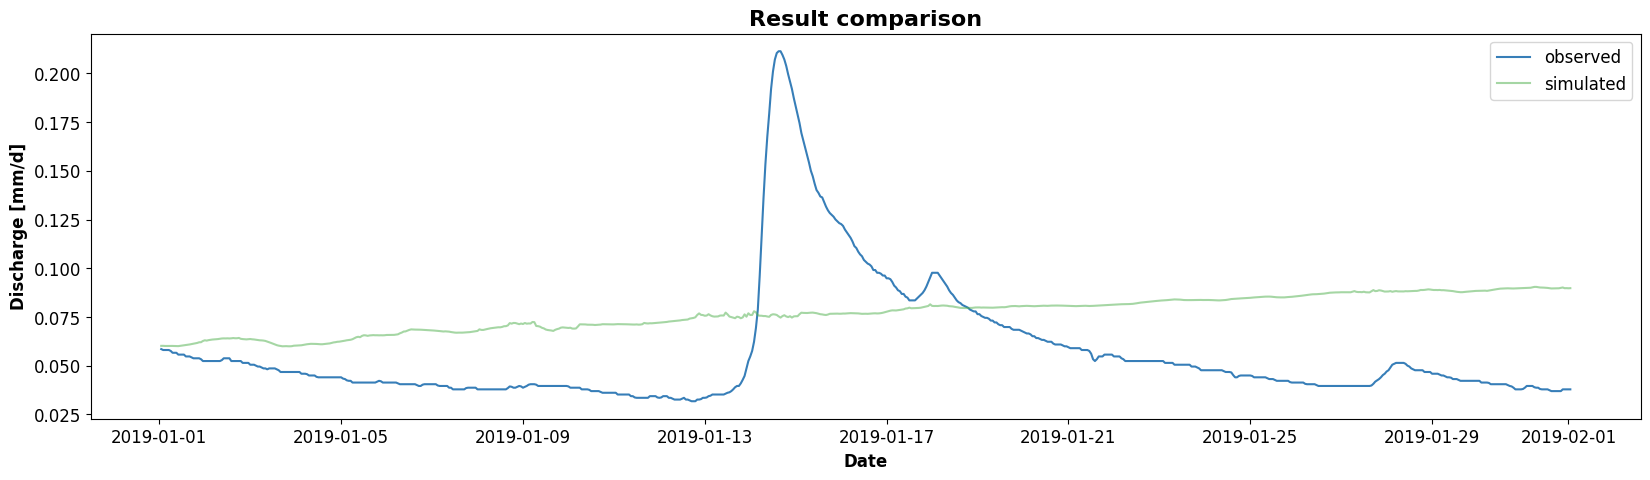

In [18]:
# Plot simulated and observed discharges
basin_to_analyze = "DE110000"

# (1) if not define output window
# plt.plot(test_results[basin_to_analyze]["y_obs"], label="observed", color=color_palette["observed"])
# plt.plot(test_results[basin_to_analyze]["y_sim"], label="simulated", alpha=0.5, color=color_palette["simulated"])

# # (2) if define output window
start_date = "2019-01-01 01:00:00"
end_date = "2019-02-01 01:00:00"
plt.plot(test_results[basin_to_analyze]["y_obs"][start_date:end_date], label="observed", color=color_palette["observed"])
plt.plot(test_results[basin_to_analyze]["y_sim"][start_date:end_date], label="simulated", alpha=0.5, color=color_palette["simulated"])


# Format plot
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Discharge [mm/d]", fontsize=12, fontweight="bold")
plt.title("Result comparison", fontsize=16, fontweight="bold")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend(loc="upper right", fontsize=12)
